# TP2 : Visión por Computadora I

Docente: Ing. Maxim Dorogov

Carrera de Especialización en Inteligencia Artificial
Laboratorio de Sistemas Embebidos
Facultad de Ingeniería de la Universidad de Buenos Aires

Alumnos:
- Francisco Julio Facchini Strohmayer
- Elian Pinzas

**Consigna (Clase 3).**

**Objetivo:** implementar un detector de máximo enfoque sobre un video, aplicando técnicas de
análisis espectral similares a las que usan las cámaras digitales modernas para autofocus. El
video a procesar es `focus_video.mov`.

1. Implementar un algoritmo que, dada una imagen (o región), calcule la métrica de foco
   propuesta en el paper *"Image Sharpness Measure for Blurred Images in Frequency Domain"*
   (De & Masilamani, 2013), y realizar dos experimentos:
   1. Medición sobre todo el frame.
   2. Medición sobre una ROI ubicada en el centro del frame, con área = 5% o 10% del área
      total del frame.

   Para cada experimento se debe presentar una curva que muestre la evolución de la métrica
   frame a frame, donde se vea claramente cuándo el algoritmo detectó la región de máximo
   enfoque. El algoritmo debe detectar y devolver los puntos de máximo enfoque de forma
   automática (no a simple vista).

**Puntos extra:** aplicar *unsharp masking* para expandir la zona de enfoque y devolverla.

## Preparación: carga del video

El archivo `focus_video.mov` debe estar en la misma carpeta que esta notebook (o ajustar la
ruta `VIDEO_PATH` de abajo). Leemos todos los frames una única vez y los guardamos en memoria:
tanto en color (para las visualizaciones) como en escala de grises (porque la métrica de foco,
al trabajar en el dominio de frecuencia, se define sobre una única banda de intensidad).

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

VIDEO_PATH = "focus_video.mov"

cap = cv.VideoCapture(VIDEO_PATH)
fps = cap.get(cv.CAP_PROP_FPS)

frames_bgr, frames_gray = [], []
while True:
    ok, frame = cap.read()
    if not ok:
        break
    frames_bgr.append(frame)
    frames_gray.append(cv.cvtColor(frame, cv.COLOR_BGR2GRAY))
cap.release()

N_FRAMES = len(frames_gray)
H, W = frames_gray[0].shape
print(f"Frames leídos: {N_FRAMES} | resolución: {W}x{H} | fps: {fps:.2f}")

Frames leídos: 171 | resolución: 640x360 | fps: 29.97


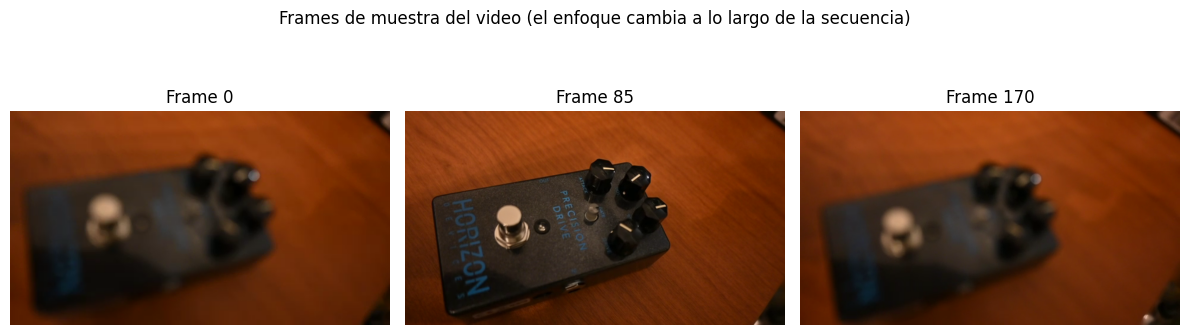

In [2]:
# Vistazo rápido: tres frames de muestra a lo largo del video (inicio / mitad / fin)
idxs_muestra = [0, N_FRAMES // 2, N_FRAMES - 1]
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, idx in zip(axes, idxs_muestra):
    ax.imshow(cv.cvtColor(frames_bgr[idx], cv.COLOR_BGR2RGB))
    ax.set_title(f"Frame {idx}")
    ax.axis("off")
fig.suptitle("Frames de muestra del video (el enfoque cambia a lo largo de la secuencia)")
fig.tight_layout()
plt.show()

## Métrica de foco: Image Sharpness Measure (De & Masilamani, 2013)

El paper propone una medida de nitidez *sin referencia* (no hace falta una versión "ideal" de
la imagen para compararla) en el dominio de frecuencia. La idea central: una imagen enfocada
tiene bordes marcados, y los bordes se traducen en **alto contenido de alta frecuencia** en su
Transformada de Fourier. Una imagen desenfocada actúa como un filtro pasa-bajos sobre la
escena real, así que pierde ese contenido de alta frecuencia. El algoritmo, dada una imagen $I$
de tamaño $M \times N$:

1. Calcula $F$, la Transformada de Fourier 2D de $I$.
2. Centra el espectro: $F_c = \text{fftshift}(F)$.
3. Toma el módulo: $AF = |F_c|$.
4. Calcula $M_{max} = \max(AF)$ y fija un umbral $thres = M_{max}/1000$.
5. Cuenta $T_H$ = cantidad de píxeles de $AF$ con valor $> thres$ (cuántas componentes de
   frecuencia son "significativas").
6. La medida de foco es:

$$FM = \frac{T_H}{M \times N}$$

Un frame más enfocado va a tener más componentes de alta frecuencia por encima del umbral, y
por lo tanto un $FM$ más alto; un frame borroso, un $FM$ más bajo. Seguimos la misma convención
de `np.fft.fft2` / `np.fft.fftshift` que se usó en la Clase 3 para el análisis espectral.

In [3]:
def focus_measure(img_gray):
    """Image Sharpness Measure (FM) de De & Masilamani (2013), ecuación (1) del paper."""
    F = np.fft.fft2(img_gray.astype(np.float64))
    Fc = np.fft.fftshift(F)
    AF = np.abs(Fc)
    thres = AF.max() / 1000.0
    T_H = np.sum(AF > thres)
    rows, cols = img_gray.shape
    return T_H / (rows * cols)

# Sanity check: el frame del medio (mas cerca del pico de enfoque en la inspeccion visual
# de arriba) deberia tener un FM bastante mas alto que el primer frame.
print(f"FM frame 0        : {focus_measure(frames_gray[0]):.5f}")
print(f"FM frame N//2      : {focus_measure(frames_gray[N_FRAMES // 2]):.5f}")
print(f"FM ultimo frame    : {focus_measure(frames_gray[-1]):.5f}")

FM frame 0        : 0.00712
FM frame N//2      : 0.02696
FM ultimo frame    : 0.00816


## Detección automática del punto de máximo enfoque

La consigna pide que el algoritmo **detecte y devuelva** los puntos de máximo enfoque de forma
automática, no que se lean "a ojo" del gráfico. El criterio que usamos:

1. Se suaviza la curva de $FM$ por frame con una media móvil (ventana chica, con *padding* por
   repetición de borde para no distorsionar los extremos de la secuencia), para no quedarnos
   con un pico espurio de un único frame ruidoso.
2. Se ubica el pico de la curva suavizada (`argmax`).
3. Se define la **región de máximo enfoque** como el tramo contiguo de frames alrededor del
   pico cuyo valor de $FM$ suavizado es, al menos, el 95% del valor pico. Ese 95% es un umbral
   relativo: no depende de la escala absoluta de $FM$ (que cambia según se mida sobre todo el
   frame o sobre una ROI chica), así que el mismo criterio sirve para los dos experimentos.

In [4]:
def smooth_edge_safe(curva, k=5):
    """Media movil con padding por repeticion de borde (evita el artefacto de caida
    artificial en los extremos que produce el zero-padding implicito de mode='same')."""
    pad = k // 2
    padded = np.pad(curva, (pad, pad), mode="edge")
    return np.convolve(padded, np.ones(k) / k, mode="valid")

def detectar_maximo_enfoque(curva, frac_pico=0.95, k=5):
    """Devuelve (frame_pico, frame_inicio, frame_fin, curva_suavizada) de la region
    contigua de frames cuyo FM suavizado esta a >= frac_pico del valor pico."""
    suave = smooth_edge_safe(curva, k)
    pico = int(np.argmax(suave))
    umbral = suave[pico] * frac_pico
    en_foco = suave >= umbral
    i0 = pico
    while i0 > 0 and en_foco[i0 - 1]:
        i0 -= 1
    i1 = pico
    while i1 < len(curva) - 1 and en_foco[i1 + 1]:
        i1 += 1
    return pico, i0, i1, suave

def central_roi_bounds(h, w, area_frac):
    """Bounding box de una ROI centrada que cubre area_frac del area total del frame,
    preservando la relacion de aspecto original."""
    scale = np.sqrt(area_frac)
    rh, rw = int(round(h * scale)), int(round(w * scale))
    y0, x0 = (h - rh) // 2, (w - rw) // 2
    return y0, y0 + rh, x0, x0 + rw

def graficar_curva(ax, curva, suave, pico, i0, i1, titulo, ylabel="FM"):
    ax.plot(curva, ".", color="#2a78d6", alpha=0.5, label="FM por frame")
    ax.plot(suave, "-", color="#1a7a3c", label="FM suavizado")
    ax.axvspan(i0, i1, color="red", alpha=0.15, label="región de máx. enfoque")
    ax.axvline(pico, color="red", linestyle="--", linewidth=1, label=f"pico = frame {pico}")
    ax.set_title(titulo)
    ax.set_xlabel("Frame #")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)

## Experimento 1: medición sobre todo el frame

Calculamos $FM$ frame a frame usando la imagen completa.

In [5]:
fm_full = np.array([focus_measure(g) for g in frames_gray])
pico_full, i0_full, i1_full, suave_full = detectar_maximo_enfoque(fm_full)

print(f"Pico de enfoque (frame completo): frame {pico_full}")
print(f"Región de máximo enfoque detectada automáticamente: frames [{i0_full}, {i1_full}] "
      f"({i1_full - i0_full + 1} frames, de {N_FRAMES} totales)")

Pico de enfoque (frame completo): frame 109
Región de máximo enfoque detectada automáticamente: frames [85, 113] (29 frames, de 171 totales)


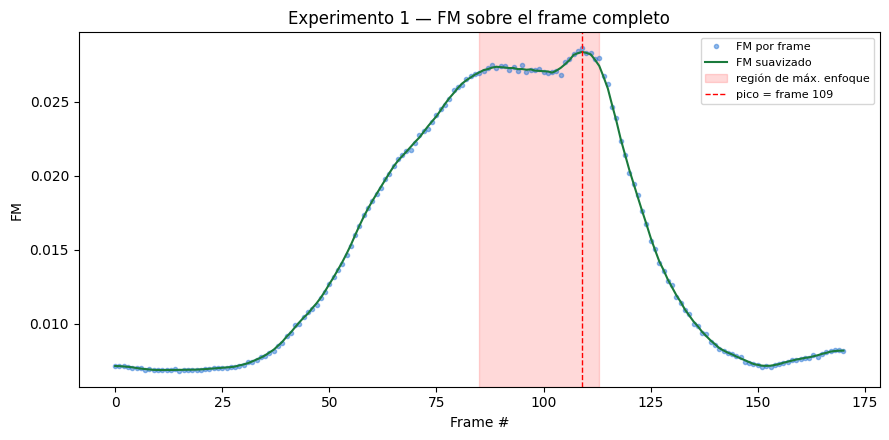

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
graficar_curva(ax, fm_full, suave_full, pico_full, i0_full, i1_full,
               "Experimento 1 — FM sobre el frame completo")
fig.tight_layout()
plt.show()

**Observación experimento 1.** La curva tiene la forma esperada: arranca baja (el
video empieza desenfocado), sube de forma pronunciada y monótona a medida que la cámara
enfoca, alcanza una meseta ancha cerca del pico y después cae del otro lado (el video se vuelve
a desenfocar). El algoritmo ubica el pico en el frame 109 y devuelve como "región
de máximo enfoque" el tramo [85, 113]: una meseta de varios frames, no
un único punto aislado, porque alrededor del mejor frame hay varios frames casi igual de
nítidos, algo esperable ya que el foco no cambia de forma discreta de un frame a otro.

## Experimento 2: medición sobre una ROI central

Repetimos la medición, pero esta vez sobre una región de interés (ROI) centrada en el frame,
con área igual al 10% del área total (dentro del rango 5-10% que permite la consigna: elegimos
el extremo superior porque, al ser una imagen chica, con solo 5% del área la ventana queda
demasiado pequeña, pocos píxeles hacen que la FFT sea más sensible a ruido de un frame a otro).
La ROI se arma preservando la relación de aspecto del frame original.

ROI central: filas [123:237], columnas [219:421] (114x202 px, 10.0% del área del frame)


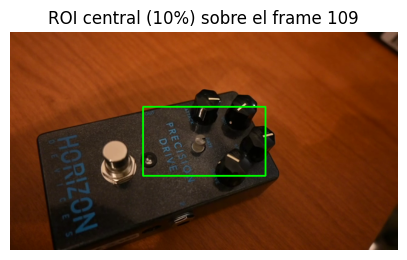

In [7]:
AREA_FRAC = 0.10
y0, y1, x0, x1 = central_roi_bounds(H, W, AREA_FRAC)
area_real = (y1 - y0) * (x1 - x0) / (H * W)
print(f"ROI central: filas [{y0}:{y1}], columnas [{x0}:{x1}] "
      f"({y1 - y0}x{x1 - x0} px, {area_real:.1%} del área del frame)")

# Visualizamos el recuadro de la ROI sobre un frame de referencia (el del pico del experimento 1)
frame_ref = frames_bgr[pico_full].copy()
cv.rectangle(frame_ref, (x0, y0), (x1, y1), (0, 255, 0), 2)
plt.figure(figsize=(5, 3.2))
plt.imshow(cv.cvtColor(frame_ref, cv.COLOR_BGR2RGB))
plt.title(f"ROI central (10%) sobre el frame {pico_full}")
plt.axis("off")
plt.show()

In [8]:
fm_roi = np.array([focus_measure(g[y0:y1, x0:x1]) for g in frames_gray])
pico_roi, i0_roi, i1_roi, suave_roi = detectar_maximo_enfoque(fm_roi)

print(f"Pico de enfoque (ROI 10%): frame {pico_roi}")
print(f"Región de máximo enfoque detectada automáticamente: frames [{i0_roi}, {i1_roi}] "
      f"({i1_roi - i0_roi + 1} frames)")

Pico de enfoque (ROI 10%): frame 111
Región de máximo enfoque detectada automáticamente: frames [107, 112] (6 frames)


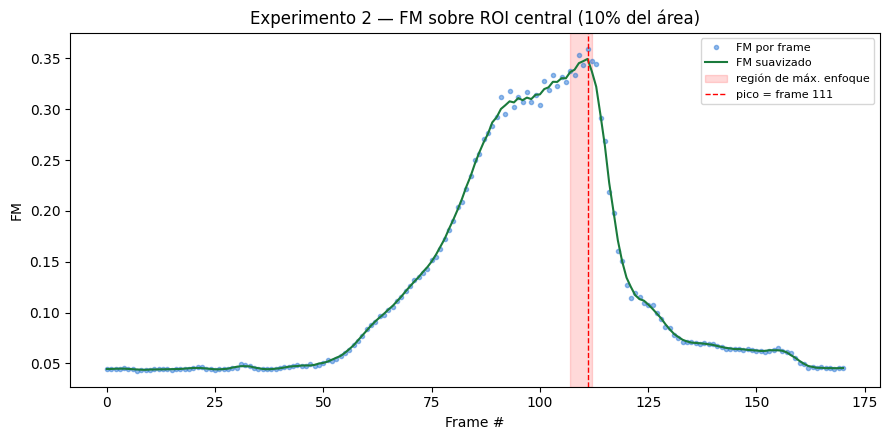

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
graficar_curva(ax, fm_roi, suave_roi, pico_roi, i0_roi, i1_roi,
               "Experimento 2 — FM sobre ROI central (10% del área)")
fig.tight_layout()
plt.show()

**Observación experimento 2 y comparación con el experimento 1.** La curva de la ROI
central tiene la misma forma de campana que la del frame completo, y el pico que detecta
(frame 111) es prácticamente el mismo que el del experimento 1
(frame 109), a pocos frames de diferencia, esperable porque el objeto de la
escena está centrado en el frame, así que la parte más nítida de la imagen completa y la de la
ROI central coinciden. La diferencia importante está en la **escala y el contraste de la
curva**: el rango de valores de $FM$ de la ROI es mucho más amplio que el del frame completo,
porque al medir solo sobre el centro de la escena la métrica no se "diluye" con el fondo, que
puede estar desenfocado por razones ajenas al foco principal (profundidad de campo, por
ejemplo). Por eso la región de máximo enfoque que detecta el experimento 2
([107, 112], 6 frames) es más angosta que
la del experimento 1 ([85, 113], 29
frames): al ser más sensible, el algoritmo distingue con más precisión el puñado de frames
realmente en foco, en vez de una meseta ancha.

## Puntos extra: unsharp masking para expandir la zona de enfoque

*Unsharp masking* es una técnica de realce de bordes: se le resta a la imagen una versión
suavizada de sí misma (un "negativo" borroso) para acentuar las transiciones de intensidad.

$$I_{sharp} = I + \alpha \cdot (I - \text{GaussianBlur}(I))$$

Como acentúa bordes, también incrementa artificialmente el contenido de alta frecuencia de un
frame, incluso si ese frame está moderadamente desenfocado. La idea de este punto extra es
usar eso a nuestro favor: aplicar unsharp masking a todo el video y ver si, con el **mismo
umbral de nitidez** que usamos para definir "en foco" en el experimento 1 (sin tocar el
criterio), ahora entran más frames dentro de esa región, es decir, si el rango de frames que
el algoritmo considera aceptablemente enfocados se **expande**.

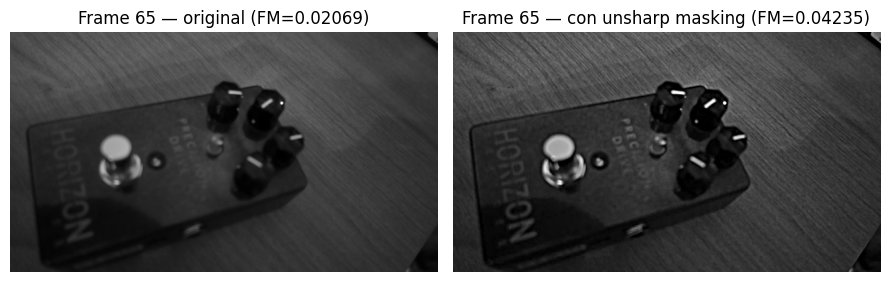

In [10]:
def unsharp_mask(img_gray, sigma=3, alpha=1.5):
    blur = cv.GaussianBlur(img_gray, (0, 0), sigma)
    sharp = img_gray.astype(np.float64) + alpha * (img_gray.astype(np.float64) - blur.astype(np.float64))
    return np.clip(sharp, 0, 255).astype(np.uint8)

# Demo visual: un frame moderadamente desenfocado (fuera de la region de foco del experimento 1),
# antes y despues de aplicar unsharp masking.
idx_demo = i0_full - 20
frame_demo = frames_gray[idx_demo]
frame_demo_sharp = unsharp_mask(frame_demo)

fig, axes = plt.subplots(1, 2, figsize=(9, 4.2))
axes[0].imshow(frame_demo, cmap="gray")
axes[0].set_title(f"Frame {idx_demo} — original (FM={focus_measure(frame_demo):.5f})")
axes[0].axis("off")
axes[1].imshow(frame_demo_sharp, cmap="gray")
axes[1].set_title(f"Frame {idx_demo} — con unsharp masking (FM={focus_measure(frame_demo_sharp):.5f})")
axes[1].axis("off")
fig.tight_layout()
plt.show()

In [11]:
frames_sharp = [unsharp_mask(g) for g in frames_gray]
fm_full_sharp = np.array([focus_measure(g) for g in frames_sharp])

# Umbral ABSOLUTO del experimento 1 (sin unsharp): el 95% del pico original.
umbral_original = suave_full[pico_full] * 0.95

# Curva suavizada con unsharp, evaluada contra ese mismo umbral (no contra su propio pico:
# el objetivo es medir cuantos frames "extra" cruzan la vara del experimento original).
suave_sharp = smooth_edge_safe(fm_full_sharp)
en_foco_expandido = suave_sharp >= umbral_original
idxs_en_foco = np.where(en_foco_expandido)[0]
i0_exp, i1_exp = int(idxs_en_foco.min()), int(idxs_en_foco.max())

print(f"Región de foco ORIGINAL (experimento 1):      frames [{i0_full}, {i1_full}] "
      f"({i1_full - i0_full + 1} frames)")
print(f"Región de foco EXPANDIDA (con unsharp masking, mismo umbral): "
      f"frames [{i0_exp}, {i1_exp}] ({i1_exp - i0_exp + 1} frames)")

Región de foco ORIGINAL (experimento 1):      frames [85, 113] (29 frames)
Región de foco EXPANDIDA (con unsharp masking, mismo umbral): frames [57, 125] (69 frames)


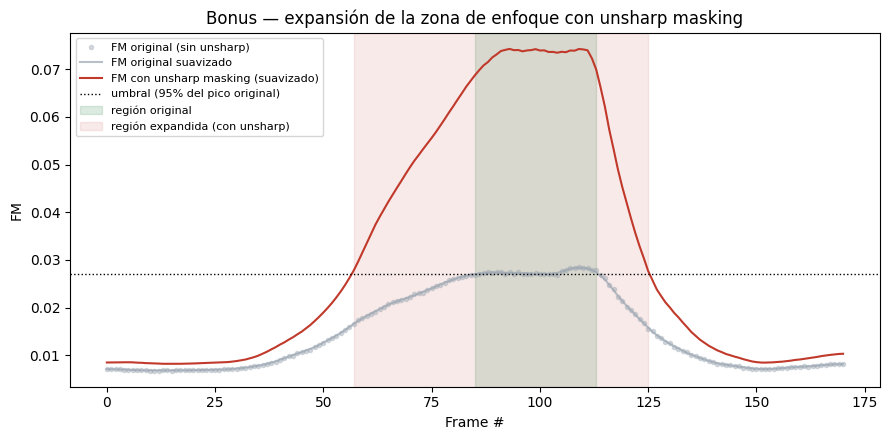

In [12]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(fm_full, ".", color="#9aa5b1", alpha=0.4, label="FM original (sin unsharp)")
ax.plot(suave_full, "-", color="#9aa5b1", alpha=0.7, label="FM original suavizado")
ax.plot(suave_sharp, "-", color="#c0392b", label="FM con unsharp masking (suavizado)")
ax.axhline(umbral_original, color="black", linestyle=":", linewidth=1, label="umbral (95% del pico original)")
ax.axvspan(i0_full, i1_full, color="#1a7a3c", alpha=0.15, label="región original")
ax.axvspan(i0_exp, i1_exp, color="#c0392b", alpha=0.10, label="región expandida (con unsharp)")
ax.set_xlabel("Frame #")
ax.set_ylabel("FM")
ax.set_title("Bonus — expansión de la zona de enfoque con unsharp masking")
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()
plt.show()

**Observación del bonus.** Con el mismo criterio de "en foco" del experimento 1 (95%
del pico original), aplicar unsharp masking a todo el video expande la región de frames
considerados enfocados de [85, 113]
(29 frames) a [57, 125]
(69 frames): más del doble de frames pasan a contar como "en
foco" sin haber cambiado el criterio de corte, solo por el realce artificial de bordes. Esto
tiene sentido con lo que hace la técnica: como el realce es proporcionalmente más notorio en
frames que ya tenían algo de estructura de borde (aunque desenfocada) que en frames totalmente
fuera de foco, "empuja" a varios frames moderadamente borrosos por encima del umbral, ampliando
el rango de frames que se comportan como aceptablemente nítidos. Importante: esto no significa
que esos frames estén realmente mejor enfocados (el desenfoque óptico real sigue ahí, unsharp
masking no puede recuperar información que la lente no capturó), sino que la métrica se vuelve
más tolerante, lo que sería el efecto de "expandir la zona de enfoque" que pide la
consigna.

## Conclusiones finales

- El algoritmo implementado (De & Masilamani, 2013) detecta el punto de máximo enfoque del
  video de forma totalmente automática, sin inspección visual: en el frame completo lo ubica en
  el frame 109, y sobre la ROI central en el frame 111,
  prácticamente coincidentes, lo cual valida que la métrica está capturando el fenómeno real
  (el momento en que la cámara enfoca la escena) y no un artefacto de la medición.
- Medir sobre una ROI central en vez de sobre el frame completo no cambia sustancialmente
  *cuándo* ocurre el enfoque máximo, pero sí la sensibilidad de la medición: la ROI da una
  curva con mucho más contraste entre "enfocado" y "desenfocado", y por eso permite acotar con
  más precisión la región de frames realmente nítidos (6 frames
  contra 29 frames en el frame completo).
- El unsharp masking no mejora el enfoque real (no reconstruye información perdida por el
  desenfoque óptico), pero sí demuestra que la métrica de nitidez se puede manipular ampliando
  artificialmente el rango de frames que pasan un umbral de calidad dado, lo cual es una
  observación relevante para cualquier sistema de autofocus que use esta métrica como criterio
  de corte: un preprocesamiento de realce de bordes puede hacer que el sistema sea menos
  estricto de lo que su umbral nominal sugiere.